# Dueling Deep Q Learning

This method is based on the already existing mehotds, however introducses new network architecture. Dueling architecture, explicitly separates the representation of state values and (state-dependent) action advantages. There are two separated streams that share common convolutional layer, as shown on figure below (on top single steam Q-network and on bottom dueling Q-network)

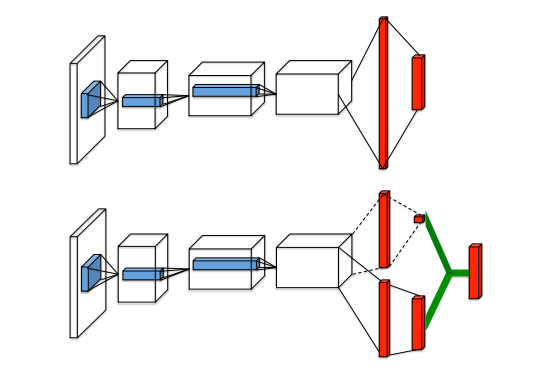

After linear layer there is a split of value and advantage functions and then get combined to get the Q, and the rst holds up the same.

Paper: https://arxiv.org/abs/1511.06581

Source code: https://github.com/MichaelAllen1966/qambo

In [1]:
import numpy as np
import pandas as pd
import random

import torch
import torch.nn as nn
import torch.optim as optim

from Environment.simulator import *
from Environment.my_utils import *

from collections import deque

import warnings

warnings.filterwarnings("ignore")

In [2]:
# SIM PARAMETERS
SLA = 2.5
VM_TYPE1 = 7
VM_TYPE2 = 3
VM_TYPE3 = 1
PENALTY = 10000
STEPS = 100
ALPHA = 0.5
BETA = 0.5
SCENARIO = "Environment/Scenarios/train_D3QN.txt"

GAMMA = 0.99
LEARNING_RATE = 1e-3
MEMORY_SIZE = 10000000
BATCH_SIZE = 5
REPLAY_START_SIZE = 50000
SYNC_TARGET_STEPS = 1000
EXPLORATION_MAX = 1.0
EXPLORATION_MIN = 0.05
EXPLORATION_DECAY = 0.9999
TRAINING_EPISODES = 100
RESULTS_NAME = 'd3qn'

In [3]:
copy_scenario('train', 'D3QN', 210)
copy_scenario('test_scenario_1', 'D3QN', 100)
copy_scenario('test_scenario_2', 'D3QN', 100)
copy_scenario('test_scenario_3', 'D3QN', 100)
copy_scenario('test_scenario_4', 'D3QN', 100)
copy_scenario('test_scenario_5', 'D3QN', 100)

Define DQN (Deep Q Network) class

In [4]:
class DQN(nn.Module):

    """Deep Q Network. Udes for both policy (action) and target (Q) networks."""

    def __init__(self, observation_space, action_space):
        """Constructor method. Set up neural nets."""
        
        # nerurones per hidden layer = 2 * max of observations or actions
        neurons_per_layer = 2 * max(observation_space, action_space)

        # Set starting exploration rate
        self.exploration_rate = EXPLORATION_MAX
        
        # Set up action space (choice of possible actions)
        self.action_space = action_space
              
        
        # First layers will be common to both Advantage and value
        super(DQN, self).__init__()
        self.feature = nn.Sequential(
            nn.Linear(observation_space, neurons_per_layer),
            nn.ReLU()  
            )
        
        # Advantage has same number of outputs as the action space
        self.advantage = nn.Sequential(
            nn.Linear(neurons_per_layer, neurons_per_layer),
            nn.ReLU(),
            nn.Linear(neurons_per_layer, action_space)
            )
        
        # State value has only one output (one value per state)
        self.value = nn.Sequential(
            nn.Linear(neurons_per_layer, neurons_per_layer),
            nn.ReLU(),
            nn.Linear(neurons_per_layer, 1)
            )        
        
    def act(self, state):
        """Act either randomly or by redicting action that gives max Q"""
        
        # Act randomly if random number < exploration rate
        if np.random.rand() < self.exploration_rate:
            action = random.randrange(self.action_space)
            
        else:
            # Otherwise get predicted Q values of actions
            q_values = self.forward(torch.FloatTensor(state))
            # Get index of action with best Q
            action = np.argmax(q_values.detach().numpy()[0])
        
        return  action
        
  
    def forward(self, x):
        x = self.feature(x)
        advantage = self.advantage(x)
        value = self.value(x)
        action_q = value + advantage - advantage.mean()
        return action_q

Define policy net training function 

In [5]:
def optimize(policy_net, target_net, memory):
    """
    Update  model by sampling from memory.
    Uses policy network to predict best action (best Q).
    Uses target network to provide target of Q for the selected next action.
    """
      
    # Do not try to train model if memory is less than reqired batch size
    if len(memory) < BATCH_SIZE:
        return    
 
    # Reduce exploration rate (exploration rate is stored in policy net)
    policy_net.exploration_rate *= EXPLORATION_DECAY
    policy_net.exploration_rate = max(EXPLORATION_MIN, 
                                      policy_net.exploration_rate)
    # Sample a random batch from memory
    batch = random.sample(memory, BATCH_SIZE)
    for state, action, reward, state_next, terminal in batch:
        
        state_action_values = policy_net(torch.FloatTensor(state))
        
        # Get target Q for policy net update
       
        if not terminal:
            # For non-terminal actions get Q from policy net
            expected_state_action_values = policy_net(torch.FloatTensor(state))
            # Detach next state values from gradients to prevent updates
            expected_state_action_values = expected_state_action_values.detach()
            # Get next state action with best Q from the policy net (double DQN)
            policy_next_state_values = policy_net(torch.FloatTensor(state_next))
            policy_next_state_values = policy_next_state_values.detach()
            best_action = np.argmax(policy_next_state_values[0].numpy())
            # Get target net next state
            next_state_action_values = target_net(torch.FloatTensor(state_next))
            # Use detach again to prevent target net gradients being updated
            next_state_action_values = next_state_action_values.detach()
            best_next_q = next_state_action_values[0][best_action].numpy()
            updated_q = reward + (GAMMA * best_next_q)      
            expected_state_action_values[0][action] = updated_q
        else:
            # For termal actions Q = reward (-1)
            expected_state_action_values = policy_net(torch.FloatTensor(state))
            # Detach values from gradients to prevent gradient update
            expected_state_action_values = expected_state_action_values.detach()
            # Set Q for all actions to reward (-1)
            expected_state_action_values[0] = reward
 
        # Set network to training mode
        policy_net.train()
        # Reset net gradients
        policy_net.optimizer.zero_grad()  
        # calculate loss
        loss_v = nn.MSELoss()(state_action_values, expected_state_action_values)
        # Backpropogate loss
        loss_v.backward()
        # Update network gradients
        policy_net.optimizer.step()  

    return

Define memory class

In [6]:
class Memory():
    """
    Replay memory used to train model.
    Limited length memory (using deque, double ended queue from collections).
      - When memory full deque replaces oldest data with newest.
    Holds, state, action, reward, next state, and episode done.
    """
    
    def __init__(self):
        """Constructor method to initialise replay memory"""
        self.memory = deque(maxlen=MEMORY_SIZE)

    def remember(self, state, action, reward, next_state, done):
        """state/action/reward/next_state/done"""
        self.memory.append((state, action, reward, next_state, done))

<b> Main program </b>

In [7]:
def run_dist_app():
    """Main program loop"""
    
    # Set up the simulation environemnt
    sim = Sim(sla = SLA,
              vm_1 = VM_TYPE1,
              vm_2 = VM_TYPE2,
              vm_3 = VM_TYPE3,
              scenario = SCENARIO,
              penalty = PENALTY,
              steps = STEPS,
              alpha = ALPHA,
              beta = BETA)

    # Get number of observations returned for state
    observation_space = 1

    # Get number of actions possible
    action_space = 7

    # Set up policy and target neural nets (and keep best net performance)
    policy_net = DQN(observation_space, action_space)
    target_net = DQN(observation_space, action_space)
    best_net = DQN(observation_space, action_space)

    # Set loss function and optimizer
    policy_net.optimizer = optim.Adam(
        params=policy_net.parameters(), lr=LEARNING_RATE)

    # Copy weights from policy_net to target
    target_net.load_state_dict(policy_net.state_dict())

    # Set target net to eval rather than training mode
    # We do not train target net - ot is copied from policy net at intervals
    target_net.eval()

    # Set up memomry
    memory = Memory()

    # Set up run counter and learning loop
    run = 0
    all_steps = 0
    continue_learning = True
    best_reward = -np.inf

    # Set up list for results  <----------------------------------------------------- FIX: change that lists
    results_run = []
    results_exploration = []
    results_score = []
    results_qos = []
    results_cost = []


    # Continue repeating games (episodes) until target complete
    while continue_learning:

        # Increment run (episode) counter
        run += 1
        
        # Reset game environment and get first state observations
        state = sim.reset()

        # Reset total reward and rewards list
        total_reward = 0
        rewards = []

        # Reshape state into 2D array with state obsverations as first 'row'
        state = np.reshape(state, [1, observation_space])

        # Continue loop until episode complete
        while True:

            # Get action to take (se eval mode to avoid dropout layers)
            policy_net.eval()
            action = policy_net.act(state)

            # Act
            state_next, reward, terminal, info = sim.step(action)
            total_reward += reward

            # Update trackers
            rewards.append(reward)

            # Reshape state into 2D array with state observations as first 'row' <--------------- Do I have to?
            state_next = np.reshape(state_next, [1, observation_space])

            # Record state, action, reward, new state & terminal
            memory.remember(state, action, reward, state_next, terminal)

            # Update state
            state = state_next

            # Actions to take if end of game episode <----------------------------------------------- Fix: to be set with lsts
            if terminal:
                # Get exploration rate
                exploration = policy_net.exploration_rate
                # Clear print row content
                # clear_row = '\r' + ' ' * 79 + '\r'
                # print(clear_row, end='')
                print(f'Run: {run}, ', end='')
                print(f'Exploration: {exploration: .3f}, ', end='')
                average_reward = np.mean(rewards)
                print(f'Average reward: {average_reward:4.1f}, ', end='')
                mean_qos = np.mean(info['Quality of Service'])
                print(f'Mean quality of service: {mean_qos:4.1f}, ', end='')
                mean_cost = np.mean(info['Current cost'])
                print(f'Mean cost: {mean_cost:4.1f}, ', end='')
                print('\n')

                # Add to results lists
                results_run.append(run)
                results_exploration.append(exploration)
                results_score.append(total_reward)
                results_qos.append(mean_qos)
                results_cost.append(mean_cost)

                # Save model if best reward
                total_reward = np.sum(rewards)
                if total_reward > best_reward:
                    best_reward = total_reward
                    # Copy weights to best net
                    best_net.load_state_dict(policy_net.state_dict())

                if run == TRAINING_EPISODES:
                    continue_learning = False

                # End episode loop
                break

            # Avoid training model if memory is not of sufficient length
            if len(memory.memory) > REPLAY_START_SIZE:

                # Update policy net
                optimize(policy_net, target_net, memory.memory)

                
                # Use load_state_dict method to copy weights from policy net
                if all_steps % SYNC_TARGET_STEPS == 0:
                    target_net.load_state_dict(policy_net.state_dict())


    
    # SAVE RESULTS <----------------------------------------------------------------------- FIX
    run_details = pd.DataFrame()
    run_details['run'] = results_run
    run_details['exploration '] = results_exploration
    run_details['mean_qos'] = results_qos
    run_details['mean_cost'] = results_cost
    
    return run_details, best_net # returns results and the best model 

In [8]:
last_run, best_net = run_dist_app()

Run: 1, Exploration:  1.000, Average reward:  0.3, Mean quality of service:  4.3, Mean cost: 230.0, 

Run: 2, Exploration:  1.000, Average reward:  0.5, Mean quality of service:  3.6, Mean cost: 595.0, 

Run: 3, Exploration:  1.000, Average reward:  0.5, Mean quality of service:  3.3, Mean cost: 570.0, 

Run: 4, Exploration:  1.000, Average reward:  0.4, Mean quality of service:  4.2, Mean cost: 155.0, 

Run: 5, Exploration:  1.000, Average reward:  0.5, Mean quality of service:  4.2, Mean cost: 240.0, 

Run: 6, Exploration:  1.000, Average reward:  0.5, Mean quality of service:  4.9, Mean cost: 450.0, 

Run: 7, Exploration:  1.000, Average reward:  0.5, Mean quality of service:  4.6, Mean cost: 525.0, 

Run: 8, Exploration:  1.000, Average reward:  0.5, Mean quality of service:  4.2, Mean cost: 370.0, 

Run: 9, Exploration:  1.000, Average reward:  0.4, Mean quality of service:  3.8, Mean cost: 345.0, 

Run: 10, Exploration:  1.000, Average reward:  0.5, Mean quality of service:  4.4,

Run: 81, Exploration:  1.000, Average reward:  0.5, Mean quality of service:  4.7, Mean cost: 435.0, 

Run: 82, Exploration:  1.000, Average reward:  0.5, Mean quality of service:  3.4, Mean cost: 660.0, 

Run: 83, Exploration:  1.000, Average reward:  0.4, Mean quality of service:  4.6, Mean cost: 220.0, 

Run: 84, Exploration:  1.000, Average reward:  0.4, Mean quality of service:  3.6, Mean cost: 280.0, 

Run: 85, Exploration:  1.000, Average reward:  0.4, Mean quality of service:  3.4, Mean cost: 295.0, 

Run: 86, Exploration:  1.000, Average reward:  0.4, Mean quality of service:  4.0, Mean cost: 440.0, 

Run: 87, Exploration:  1.000, Average reward:  0.5, Mean quality of service:  4.2, Mean cost: 545.0, 

Run: 88, Exploration:  1.000, Average reward:  0.5, Mean quality of service:  4.4, Mean cost: 355.0, 

Run: 89, Exploration:  1.000, Average reward:  0.5, Mean quality of service:  3.4, Mean cost: 550.0, 

Run: 90, Exploration:  1.000, Average reward:  0.4, Mean quality of servi

Test the best model

info {'Quality of Service': 3.4219620356179705, 'Current cost': 660, 'Queue': [7, 7, 7, 7, 7, 7, 7, 7, 7, 7], 'Timer': 2.922300100326538, 'VM type I': 6, 'VM type II': 9, 'VM type III': 3}


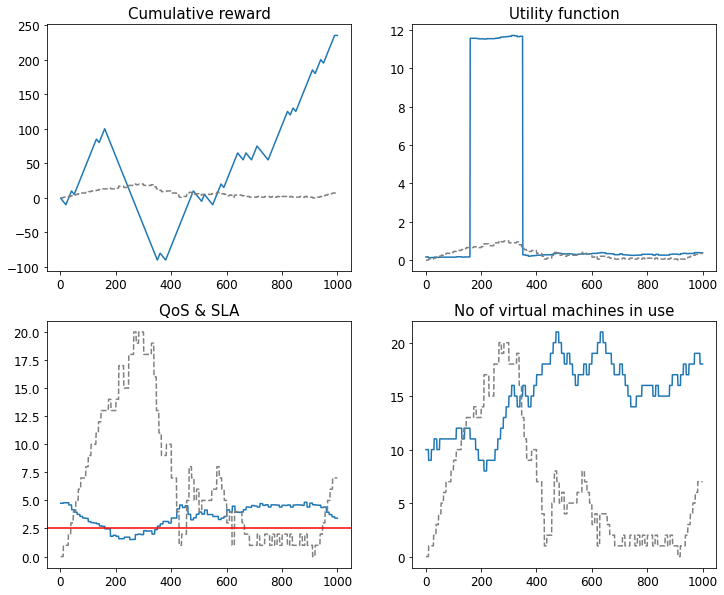

Cumulative reward at the end of the test:  235.0
Avg cost minus penalty per step:  2.43
Avg quality of service:  3.62
Avg no of virtual machines:  15.11


In [9]:
SCENARIO = 'Environment/Scenarios/test_scenario_1_D3QN.txt'
test_model_Qlearning(best_net, SLA, VM_TYPE1, VM_TYPE2, VM_TYPE3, STEPS, SCENARIO, PENALTY, ALPHA, BETA)

info {'Quality of Service': 3.761478223749583, 'Current cost': 530, 'Queue': [5, 6, 6, 6, 6, 6, 6, 6, 6, 6], 'Timer': 2.658529281616211, 'VM type I': 12, 'VM type II': 4, 'VM type III': 2}


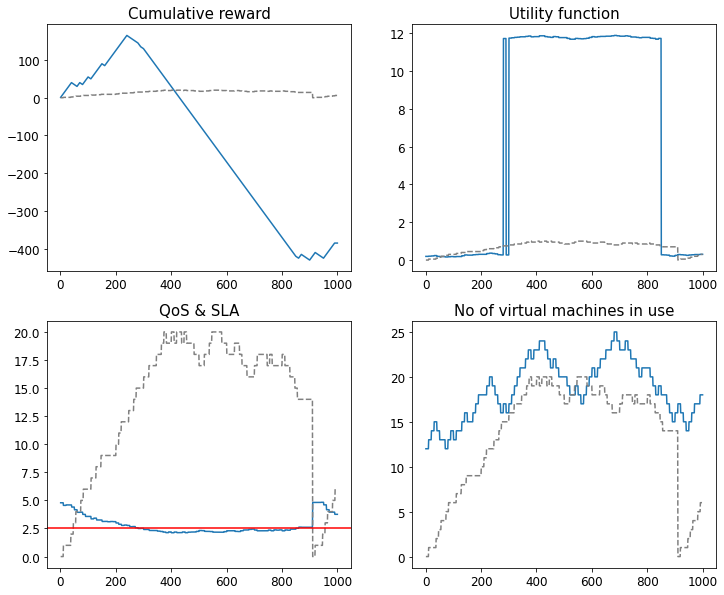

Cumulative reward at the end of the test:  -385.0
Avg cost minus penalty per step:  6.71
Avg quality of service:  2.82
Avg no of virtual machines:  18.63


In [10]:
SCENARIO = 'Environment/Scenarios/test_scenario_2_D3QN.txt'
test_model_Qlearning(best_net, SLA, VM_TYPE1, VM_TYPE2, VM_TYPE3, STEPS, SCENARIO, PENALTY, ALPHA, BETA)

info {'Quality of Service': 2.52798558682534, 'Current cost': 690, 'Queue': [15, 14, 14, 14, 14, 14, 14, 14, 14, 14], 'Timer': 3.955718755722046, 'VM type I': 15, 'VM type II': 9, 'VM type III': 1}


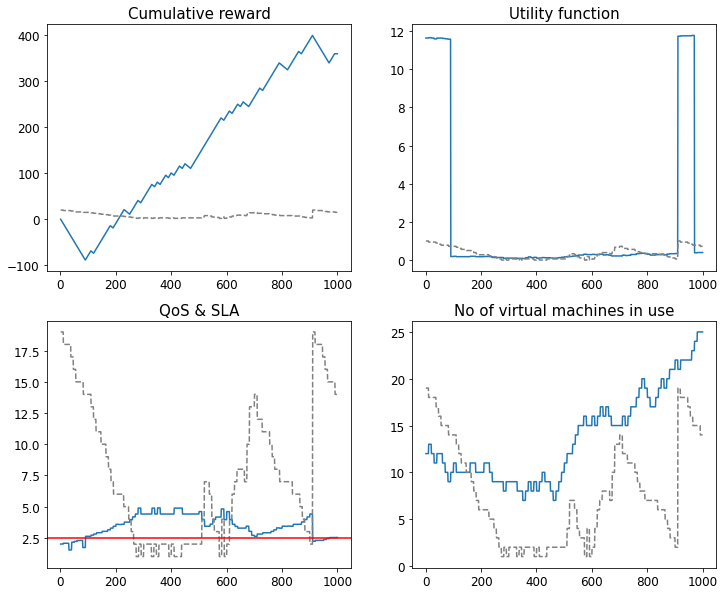

Cumulative reward at the end of the test:  360.0
Avg cost minus penalty per step:  1.93
Avg quality of service:  3.48
Avg no of virtual machines:  13.67


In [11]:
SCENARIO = 'Environment/Scenarios/test_scenario_3_D3QN.txt'
test_model_Qlearning(best_net, SLA, VM_TYPE1, VM_TYPE2, VM_TYPE3, STEPS, SCENARIO, PENALTY, ALPHA, BETA)

info {'Quality of Service': 2.291089395226282, 'Current cost': 310, 'Queue': [16, 17, 17, 17, 17, 17, 17, 17, 17, 17], 'Timer': 4.364735841751099, 'VM type I': 8, 'VM type II': 0, 'VM type III': 2}


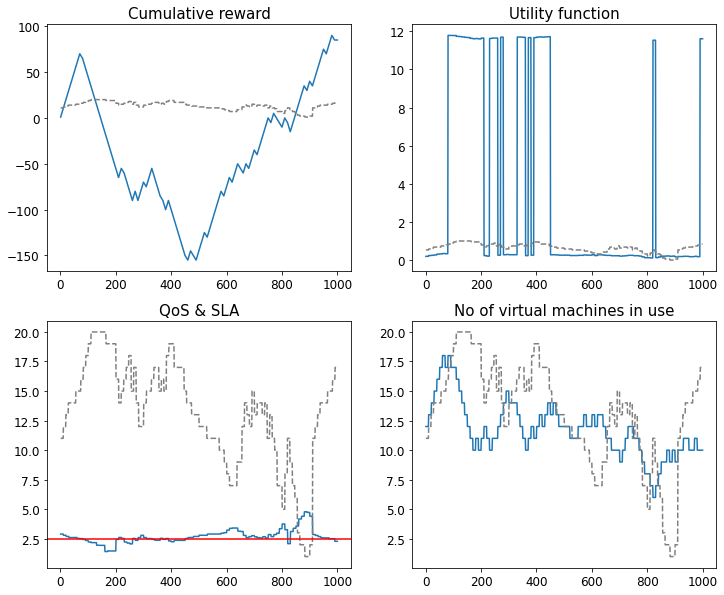

Cumulative reward at the end of the test:  85.0
Avg cost minus penalty per step:  3.55
Avg quality of service:  2.71
Avg no of virtual machines:  11.77


In [12]:
SCENARIO = 'Environment/Scenarios/test_scenario_4_D3QN.txt'
test_model_Qlearning(best_net, SLA, VM_TYPE1, VM_TYPE2, VM_TYPE3, STEPS, SCENARIO, PENALTY, ALPHA, BETA)

info {'Quality of Service': 3.761702900103982, 'Current cost': 515, 'Queue': [5, 4, 4, 4, 4, 4, 4, 4, 4, 4], 'Timer': 2.6583704948425293, 'VM type I': 6, 'VM type II': 7, 'VM type III': 2}


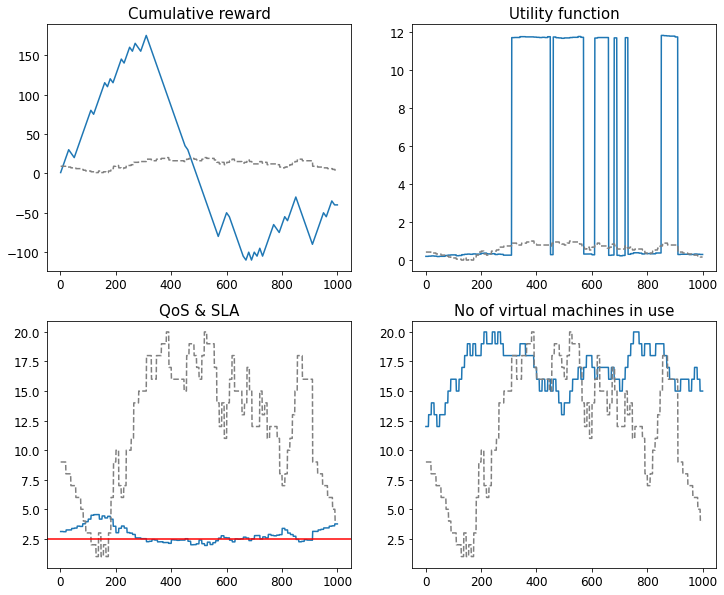

Cumulative reward at the end of the test:  -40.0
Avg cost minus penalty per step:  4.63
Avg quality of service:  2.88
Avg no of virtual machines:  16.76


In [13]:
SCENARIO = 'Environment/Scenarios/test_scenario_5_D3QN.txt'
test_model_Qlearning(best_net, SLA, VM_TYPE1, VM_TYPE2, VM_TYPE3, STEPS, SCENARIO, PENALTY, ALPHA, BETA)